### Compare SESN models with Khakpash+24 results

In [1]:
from caat import SNModel
from caat.utils import ROOT_DIR, WLE
import os
import pickle as pkl
import matplotlib.pyplot as plt


In [2]:
# Load Khakpash+24 model grid
with open(os.path.join(ROOT_DIR, "data", "comparison_models", "Khakpash24", "all_templates.pkl"), 'rb') as f:
    u = pkl._Unpickler(f)
    u.encoding = 'latin1'
    tmpl = u.load()

# Generate multi-D GP model
snmodel = SNModel(
    surface="SESNe_SNIIb_GP_model.fits"
)

bands_to_plot = ["w1", "U", "B", "V", "g", "rp", "ip"]
sntype = "IIb"

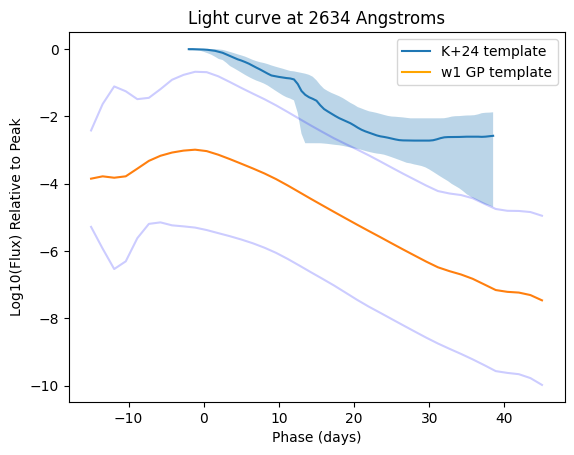

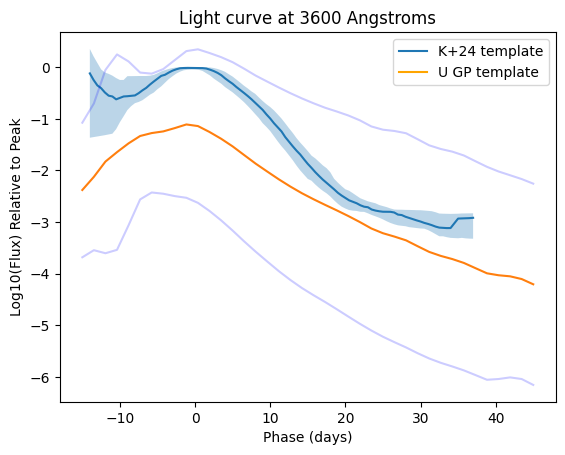

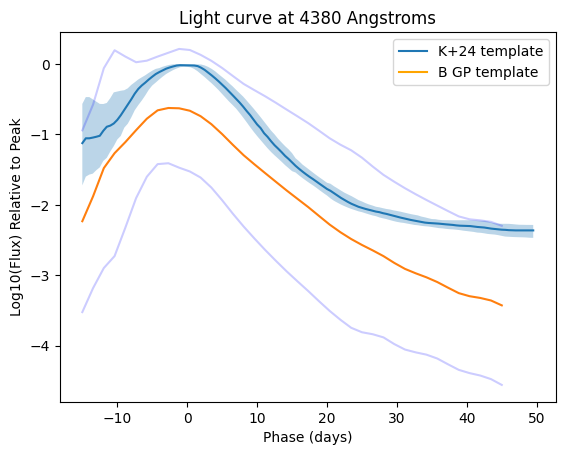

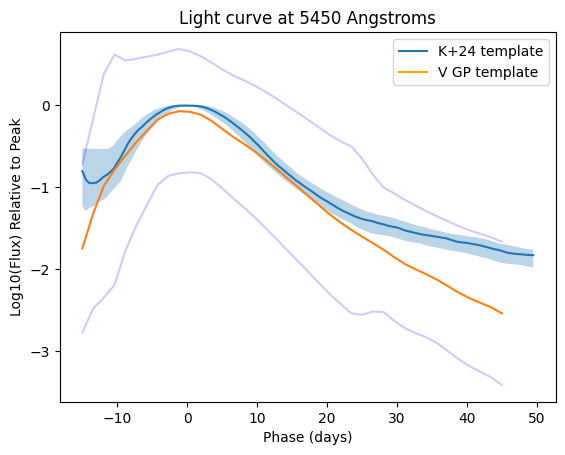

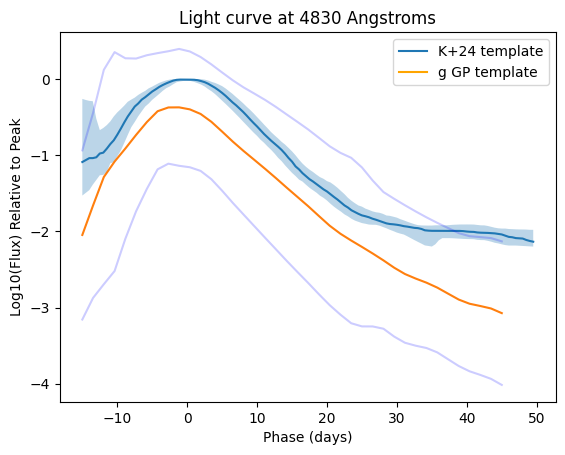

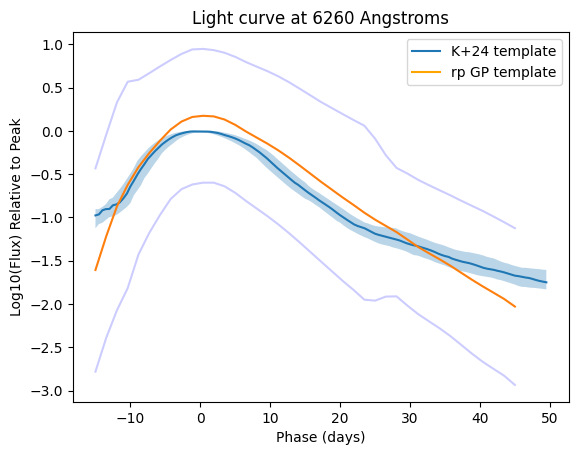

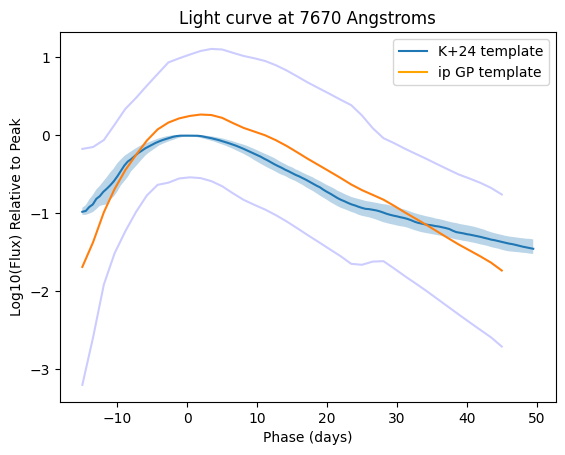

In [3]:
for band in bands_to_plot:
    _, ax = plt.subplots()
    ax.plot(tmpl[band][sntype]['t'], tmpl[band][sntype]['rollingMedian'], label="K+24 template")
    ax.fill_between(
        tmpl[band][sntype]['t'],
        tmpl[band][sntype]['rollingPc25'],
        tmpl[band][sntype]['rollingPc75'],
        alpha=0.3,
    )

    if band in ["w2", "m2", "w1"]:
        caat_band = "UV" + band.upper()
    else:
        caat_band = band[0]
    snmodel.predict_lightcurve(-15.0, 45.0, WLE[caat_band], show=False)
    plt.plot([], [], color='orange', label=f"{band} GP template")
    plt.legend()
    plt.show()

In [4]:
import os
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from caat import SN
from caat.utils import colors as FILTER_COLORS
from caat.utils import ROOT_DIR, WLE
from util import load_datacube


# Filters present in the GOPREAUX model and their K24 band equivalents
BAND_MAP = {
    # GOPREAUX filter : K24 band name
    "UVW2": "w2",
    "UVM2": "m2",
    "UVW1": "w1",
    "U": "U",
    "B": "B",
    "V": "V",
    "g": "g",
    "r": "rp",
    "i": "ip",
}

MIN_PHASE = -15
MAX_PHASE = 45


In [5]:
from util import _gopreaux_filter_peak


def predict_khakpash(
    tmpl: dict,
    model,
    obs: pd.DataFrame,
    sn_subtype: str,
    band_map: dict,
    peak_filt: str,
    plot: bool = True,
) -> pd.DataFrame:
    """
    Interpolate Khakpash+24 templates at observed phases, normalised to the
    per-SN peak filter (matching the observed MagFromPeak zero-point).

    Normalization alignment
    -----------------------
    K24 templates peak at 0 per filter.  GOPREAUX peaks at 0 at its native
    reference (typically g-band).  The observed photometry peaks at 0 at the
    SN's actual peak_filt.

    For each filter f:
        gop_f_peak   = GOPREAUX model peak in filter f  (vs. native reference)
        gop_ref_peak = GOPREAUX model peak in peak_filt (vs. native reference)
        K24_f_adjusted = K24_f + (gop_f_peak - gop_ref_peak)

    This shifts K24 so that filter peak_filt peaks at gop_ref_peak - gop_ref_peak = 0,
    matching the observed zero-point, and all other filters are offset consistently.

    Returns obs with added columns (log10(flux) units, relative to peak_filt):
        K24_mag  – interpolated K24 median
        K24_lo   – 25th-percentile bound
        K24_hi   – 75th-percentile bound
    """
    SUBTYPE_MAP = {"SNIIb": "IIb", "SNIb": "Ib", "SNIc": "Ic", "SNIc-BL": "Ic-bl"}

    if obs.empty:
        return obs.assign(K24_mag=np.nan, K24_lo=np.nan, K24_hi=np.nan)

    sntype = SUBTYPE_MAP.get(sn_subtype, sn_subtype)

    # Reference offset: GOPREAUX peak in the SN's actual reference filter
    gop_ref_peak = _gopreaux_filter_peak(model, WLE[peak_filt])

    # Per-filter GOPREAUX peak offsets relative to native model reference
    filter_offsets: dict[str, float] = {}
    for gopreaux_filt, k24_band in band_map.items():
        if gopreaux_filt not in obs["Filter"].values:
            continue
        if k24_band not in tmpl or sntype not in tmpl[k24_band]:
            continue
        wl = float(obs[obs["Filter"] == gopreaux_filt]["Wavelength"].iloc[0])
        filter_offsets[gopreaux_filt] = _gopreaux_filter_peak(model, wl) - gop_ref_peak

    k24_mags, k24_lo_vals, k24_hi_vals = [], [], []

    for _, row in obs.iterrows():
        gopreaux_filt = row["Filter"]
        k24_band = band_map.get(gopreaux_filt)

        if (
            k24_band is None
            or k24_band not in tmpl
            or sntype not in tmpl[k24_band]
            or gopreaux_filt not in filter_offsets
            or len(tmpl[k24_band][sntype]) == 0
        ):
            k24_mags.append(np.nan)
            k24_lo_vals.append(np.nan)
            k24_hi_vals.append(np.nan)
            continue

        d      = tmpl[k24_band][sntype]
        offset = filter_offsets[gopreaux_filt]

        interp_med = interp1d(d["t"], d["rollingMedian"] + offset, bounds_error=False, fill_value=np.nan)
        interp_lo  = interp1d(d["t"], d["rollingPc25"]   + offset, bounds_error=False, fill_value=np.nan)
        interp_hi  = interp1d(d["t"], d["rollingPc75"]   + offset, bounds_error=False, fill_value=np.nan)

        k24_mags.append(float(interp_med(row["Phase"])))
        k24_lo_vals.append(float(interp_lo(row["Phase"])))
        k24_hi_vals.append(float(interp_hi(row["Phase"])))

    result = obs.copy()
    result["K24_mag"] = k24_mags
    result["K24_lo"]  = k24_lo_vals
    result["K24_hi"]  = k24_hi_vals

    if plot:
        filters = [f for f in result["Filter"].unique()
                   if not result[result["Filter"] == f]["K24_mag"].isna().all()]
        if filters:
            fig, axes = plt.subplots(1, len(filters), figsize=(4 * len(filters), 4),
                                     sharey=True, squeeze=False)
            for ax, filt in zip(axes[0], filters):
                grp   = result[result["Filter"] == filt].sort_values("Phase")
                color = FILTER_COLORS.get(filt, "steelblue")

                ax.errorbar(
                    grp["Phase"], grp["ShiftedMag"], yerr=grp["Magerr"],
                    fmt="o", color=color, label="Observed", zorder=3,
                )
                ax.plot(grp["Phase"], grp["K24_mag"], color="tomato", label="K24", zorder=2)
                ax.fill_between(grp["Phase"], grp["K24_lo"], grp["K24_hi"],
                                color="tomato", alpha=0.2, zorder=1)
                ax.set_xlabel("Phase (days)")
                ax.set_title(filt)
                ax.legend(fontsize=8)

            axes[0][0].set_ylabel(f"log₁₀(flux) relative to {peak_filt}-peak")
            fig.suptitle(f"K24 ({sntype}) vs. observed", y=1.02)
            plt.tight_layout()
            plt.show()

    return result


In [6]:
from util import compute_metrics, get_observed_points, predict_gopreaux


def evaluate_sn(sn_name: str, sn_type: str, sn_subtype: str, model, tmpl: dict, peak_filter: str, plot: bool = False) -> pd.DataFrame:
    """
    Run both model predictions for a single hold-out SN and return a
    tidy DataFrame of metrics per filter.

    Args:
        sn_name: IAU name (e.g. 'SN2019hcc')
        model:   loaded SNModel object

    Returns:
        DataFrame with columns:
            SN, Filter, n_points,
            GOPREAUX_bias, GOPREAUX_mad, GOPREAUX_iqr, GOPREAUX_chi2,
            Khakpash_bias,    Khakpash_mad,    Khakpash_iqr,    Khakpash_chi2
    """
    cube = load_datacube(sn_name, sn_type, sn_subtype, min_phase=MIN_PHASE, max_phase=MAX_PHASE)
    obs  = get_observed_points(cube, BAND_MAP)
    if obs.empty:
        print(f"  {sn_name}: no usable detections in BAND_MAP filters")
        return pd.DataFrame()

    obs = predict_gopreaux(model, obs, peak_filter, plot=plot)
    obs = predict_khakpash(tmpl, model, obs, sn_subtype, BAND_MAP, peak_filter, plot=plot)

    rows = []
    for filt, group in obs.groupby("Filter"):
        gp_resid = (group["GOPREAUX_mag"] - group["ShiftedMag"]).values
        kp_resid = (group["K24_mag"]     - group["ShiftedMag"]).values
        errs     = np.sqrt(group["Magerr"].values**2 + group["GOPREAUX_err"].values**2)

        gp_metrics = compute_metrics(gp_resid, errs)
        kp_metrics = compute_metrics(kp_resid, errs)

        # Drop bands with fewer than 5 data points from the analysis
        if gp_metrics["n"] > 4:
            rows.append({
                "SN":              sn_name,
                "Filter":          filt,
                "n_points":        gp_metrics["n"],
                "GOPREAUX_bias":   gp_metrics["bias"],
                "GOPREAUX_mad":    gp_metrics["mad"],
                "GOPREAUX_iqr":    gp_metrics["iqr"],
                "GOPREAUX_chi2":   gp_metrics["chi2_reduced"],
                "Khakpash_bias":      kp_metrics["bias"],
                "Khakpash_mad":       kp_metrics["mad"],
                "Khakpash_iqr":       kp_metrics["iqr"],
                "Khakpash_chi2":      kp_metrics["chi2_reduced"],
            })

    return pd.DataFrame(rows)

In [7]:
from caat import SN, SNModel, SNCollection
from util import CUBE_ROOT

sn_subtype = "SNIc"
snmodel = SNModel(
    surface=f"SESNe_{sn_subtype}_GP_model.fits"
)
plot = False

with open(os.path.join(ROOT_DIR, "data", "comparison_models", "Khakpash24", "all_templates.pkl"), 'rb') as f:
    u = pkl._Unpickler(f)
    u.encoding = 'latin1'
    tmpl = u.load()

OBJECTS_TO_MODEL = [
    sn.name for sn in SNCollection(sntype="SESNe", snsubtype=sn_subtype).sne
]

all_results = []
for sn_name in OBJECTS_TO_MODEL:
    sn_obj = SN(name=sn_name)
    peak_filter = sn_obj.info.get("peak_filt", "")
    cube_path = os.path.join(CUBE_ROOT, "SESNe", sn_subtype, sn_name, f"{sn_name}_datacube_mangled.csv")

    if not peak_filter or not os.path.exists(cube_path):
        continue

    print(f"Evaluating {sn_name} (peak_filt={peak_filter})...")
    result = evaluate_sn(sn_name, "SESNe", sn_subtype, snmodel, tmpl, peak_filter, plot=plot)
    if not result.empty:
        all_results.append(result)

results = pd.concat(all_results, ignore_index=True)
results


INFO:caat.SNCollection:Loading SN Type: SESNe, Subtype: SNIc
INFO:caat.SNCollection:['SN2016iae' 'SN2021do' 'SN2012cw' 'SN2007D' 'SN2015fn' 'SN2018lei'
 'SN2020sgf' 'SN2021afuq' 'SN2021dwg' 'SN2005ek' 'SN2009mi' 'SN2019yz'
 'SN2019cad' 'SN2010ah' 'SN2020lbh' 'SN2018avk' 'SN2023dbc' 'SN2018kzr'
 'SN2005da' 'SN2022epu' 'SN2011it' 'SN2020adow' 'SN2021uyc' 'SN2009bb'
 'SN2021mxx' 'SN2007bg' 'SN2017ein' 'SN2023cpt' 'SN2010S' 'SN2023jac'
 'SN2008fz' 'SN2023cj' 'SN2020oi' 'SN2007I' 'SN2022jli' 'SN2020scb'
 'SN2002ap' 'SN2003jd' 'SN2004aw' 'SN2004fe' 'SN2004gk' 'SN2004gt'
 'SN2005az' 'SN2005kf' 'SN2005kl' 'SN2005kz' 'SN2005mf' 'SN2005nb'
 'SN2006aj' 'SN2006ck' 'SN2006ir' 'SN2007aw' 'SN2007ce' 'SN2007cl'
 'SN2007gr' 'SN2007hb' 'SN2007iq' 'SN2007ru' 'SN2007rz' 'SN2008an'
 'SN2008hh']


Evaluating SN2016iae (peak_filt=o)...
  SN2016iae: no usable detections in BAND_MAP filters
Evaluating SN2021do (peak_filt=g)...
Evaluating SN2020sgf (peak_filt=g)...
Evaluating SN2021dwg (peak_filt=o)...
Evaluating SN2019yz (peak_filt=o)...
Evaluating SN2019cad (peak_filt=g)...
Evaluating SN2020lbh (peak_filt=o)...
  SN2020lbh: no usable detections in BAND_MAP filters
Evaluating SN2023dbc (peak_filt=o)...
Evaluating SN2022epu (peak_filt=o)...
Evaluating SN2020adow (peak_filt=g)...
Evaluating SN2021uyc (peak_filt=g)...
Evaluating SN2009bb (peak_filt=g)...
Evaluating SN2021mxx (peak_filt=g)...
Evaluating SN2007bg (peak_filt=V)...
Evaluating SN2017ein (peak_filt=g)...
Evaluating SN2023cpt (peak_filt=o)...
Evaluating SN2023jac (peak_filt=g)...
Evaluating SN2023cj (peak_filt=o)...
  SN2023cj: no usable detections in BAND_MAP filters
Evaluating SN2020oi (peak_filt=g)...
Evaluating SN2020scb (peak_filt=g)...
Evaluating SN2003jd (peak_filt=V)...
Evaluating SN2004aw (peak_filt=V)...
Evaluating

,SN,Filter,n_points,GOPREAUX_bias,GOPREAUX_mad,GOPREAUX_iqr,GOPREAUX_chi2,Khakpash_bias,Khakpash_mad,Khakpash_iqr,Khakpash_chi2
0,SN2021do,g,26,-0.133050,0.188694,0.407762,0.272850,0.314025,0.173274,0.324083,0.383770
1,SN2021do,i,13,-0.137138,0.095547,0.129699,0.157715,0.162141,0.143489,0.281771,0.334312
2,SN2021do,r,26,-0.183654,0.125341,0.239389,0.269409,0.116037,0.074815,0.131010,0.349622
3,SN2020sgf,g,34,-1.857218,0.842346,1.503898,7.034463,-1.222234,0.486526,0.986120,3.375337
4,SN2020sgf,r,38,-1.479156,0.516855,0.910685,4.430305,-1.206517,0.489253,1.030191,3.805486
...,...,...,...,...,...,...,...,...,...,...,...
106,SN2007gr,r,20,0.355460,0.116954,0.310016,0.316497,0.163141,0.107270,0.198602,0.111245
107,SN2007ru,B,11,-0.761116,0.043815,0.091833,1.150994,-0.149070,0.064560,0.108337,0.155151
108,SN2007ru,V,13,-0.622191,0.087223,0.165617,0.959053,-0.262618,0.082000,0.160726,0.262172
109,SN2007ru,i,12,-0.110282,0.065814,0.127622,0.048835,0.078601,0.124794,0.390168,0.079048


Median MAD and reduced chi^2 per filter (lower is better):

        GOPREAUX_mad  Khakpash_mad  GOPREAUX_chi2  Khakpash_chi2
Filter                                                          
B           0.149077      0.150907       0.613955       0.608255
U           0.297630      0.258118       2.172982       1.315641
UVM2        0.238995           NaN       4.424004            NaN
UVW1        0.300246           NaN       4.945098            NaN
UVW2        0.281738           NaN       2.590562            NaN
V           0.129782      0.113998       0.351410       0.207184
g           0.213688      0.142143       0.648988       0.383770
i           0.119117      0.096635       0.313806       0.331984
r           0.140430      0.110512       0.393674       0.336704


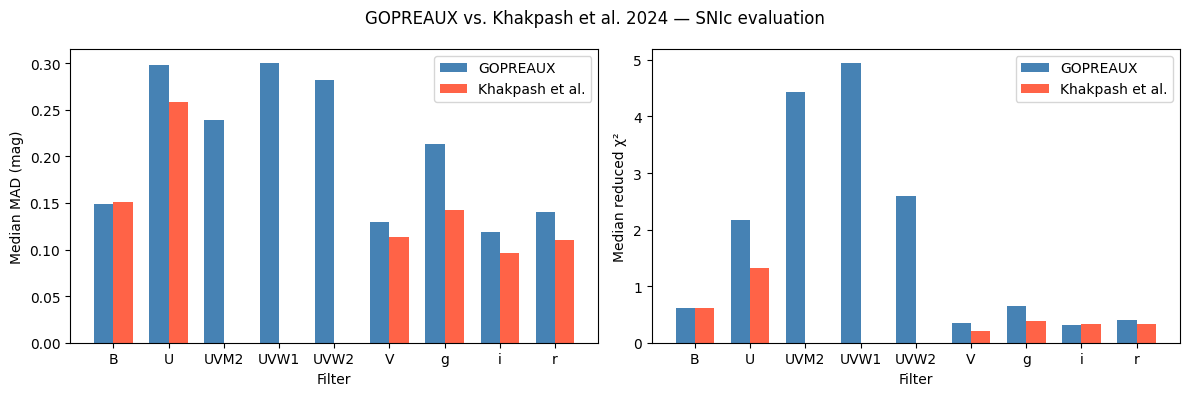

In [8]:
import matplotlib.pyplot as plt

# Summary: median MAD per model across all hold-out SNe and filters
summary = results.groupby("Filter")[["GOPREAUX_mad", "Khakpash_mad", "GOPREAUX_chi2", "Khakpash_chi2"]].median()
print("Median MAD and reduced chi^2 per filter (lower is better):\n")
print(summary.to_string())

# Bar chart: MAD by filter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(summary))
width = 0.35

for ax, metric, label in zip(
    axes,
    [("GOPREAUX_mad", "Khakpash_mad"), ("GOPREAUX_chi2", "Khakpash_chi2")],
    ["Median MAD (mag)", "Median reduced χ²"],
):
    gp_vals = summary[metric[0]].values
    k24_vals = summary[metric[1]].values
    ax.bar([i - width/2 for i in x], gp_vals, width, label="GOPREAUX", color="steelblue")
    ax.bar([i + width/2 for i in x], k24_vals, width, label="Khakpash et al.", color="tomato")
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary.index)
    ax.set_ylabel(label)
    ax.set_xlabel("Filter")
    ax.legend()

fig.suptitle(f"GOPREAUX vs. Khakpash et al. 2024 — {sn_subtype} evaluation")
plt.tight_layout()
plt.show()